#Xp flower classification

In [16]:
# Exercises XP : Flower Classification using CNN
# Classification de 14 espèces de fleurs avec un réseau CNN

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

import os
print(os.path.exists('/content/drive/MyDrive/Flower Classification.zip'))

import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/Flower Classification.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/Flower Classification')

print(os.listdir('/content/Flower Classification'))

# Dimensions des images et paramètres globaux
HEIGHT = 48
WIDTH  = 48
BATCH_SIZE = 32
NUM_CLASSES = 14
EPOCHS = 20

TRAIN_DIR = '/content/Flower Classification/Data/train'
VAL_DIR   = '/content/Flower Classification/Data/val'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True
['Data']


Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.
Classes détectées : ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']
astilbe: 726 images
bellflower: 872 images
black_eyed_susan: 986 images
calendula: 1011 images
california_poppy: 1021 images
carnation: 924 images
common_daisy: 978 images
coreopsis: 1035 images
dandelion: 1038 images
iris: 1041 images
rose: 986 images
sunflower: 1013 images
tulip: 1034 images
water_lily: 977 images


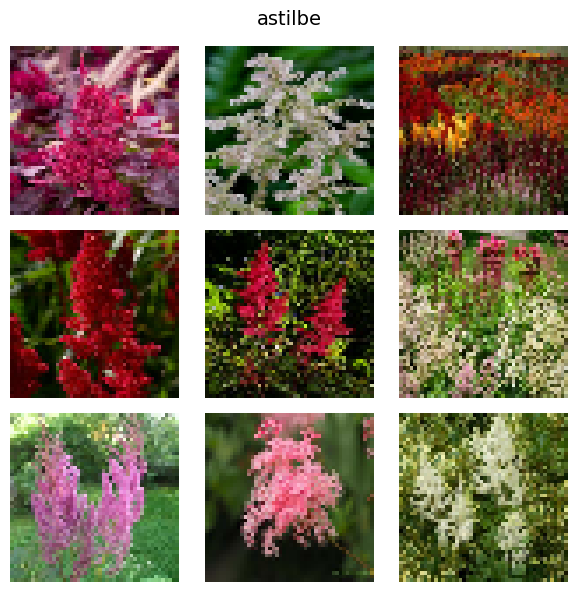

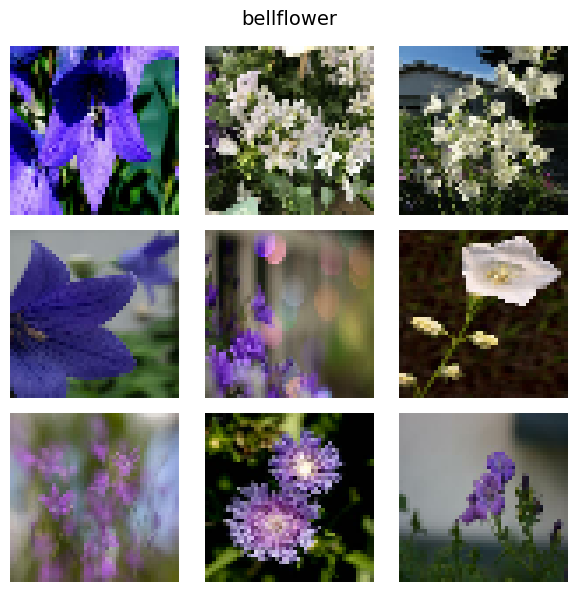

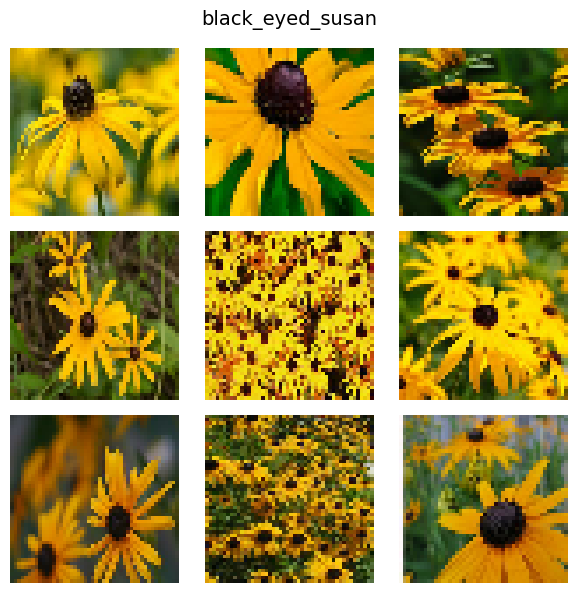

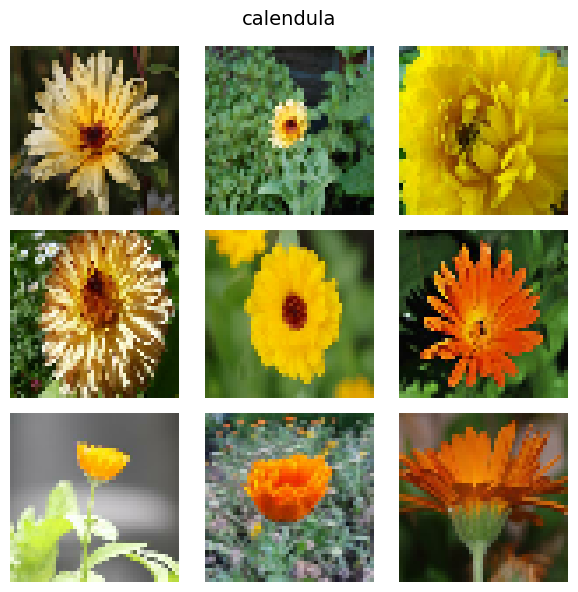

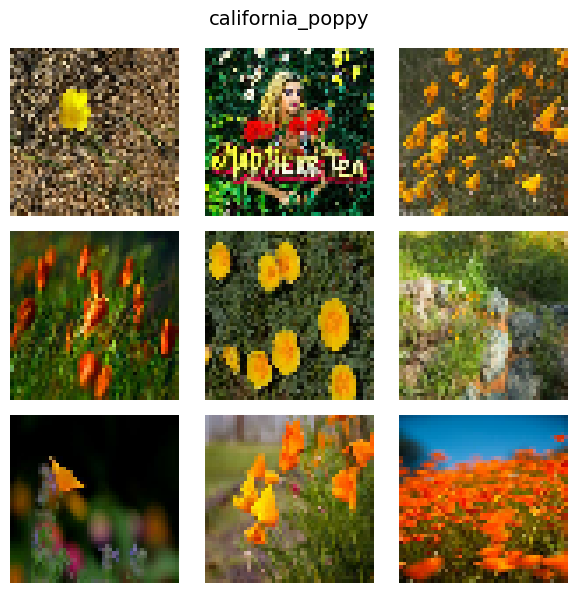

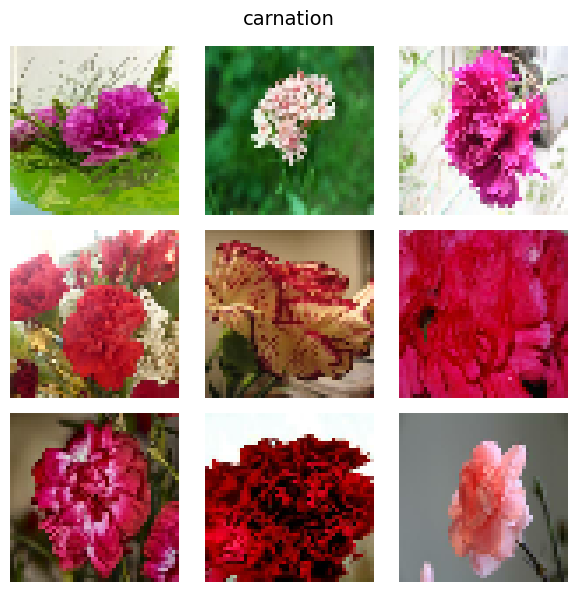

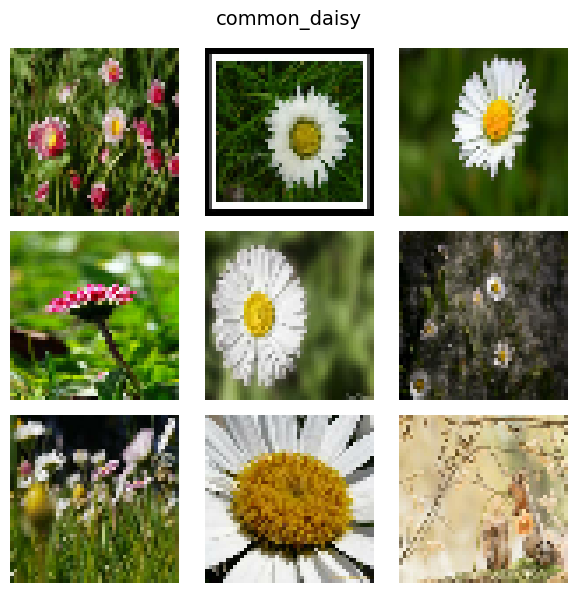

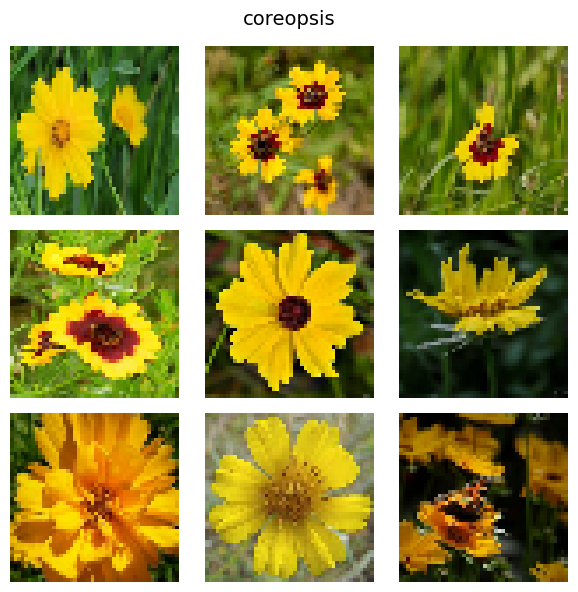

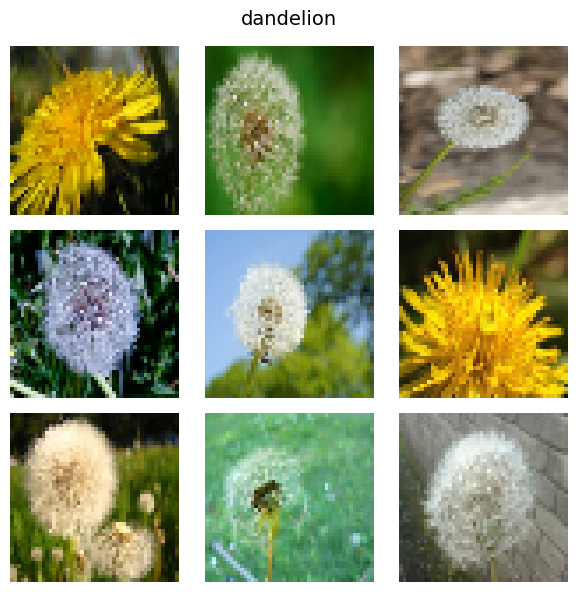

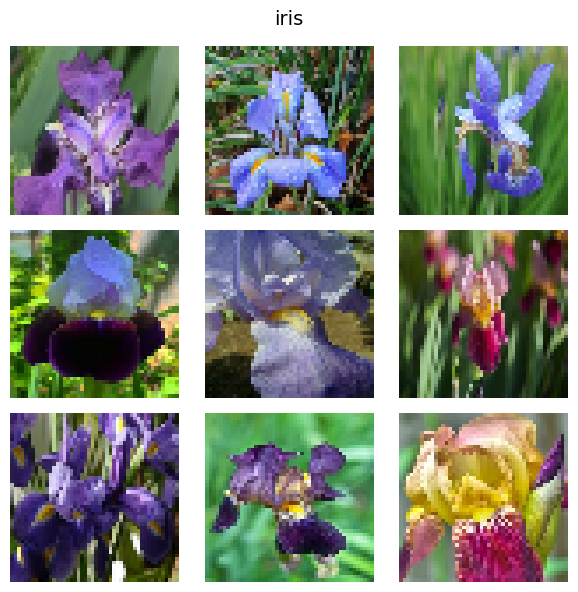

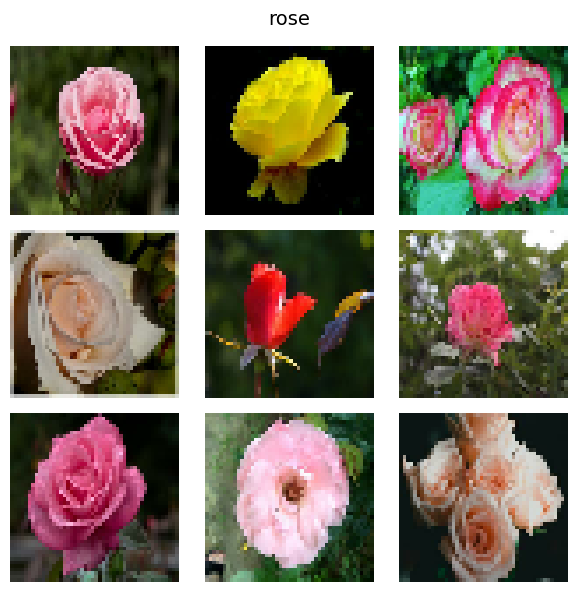

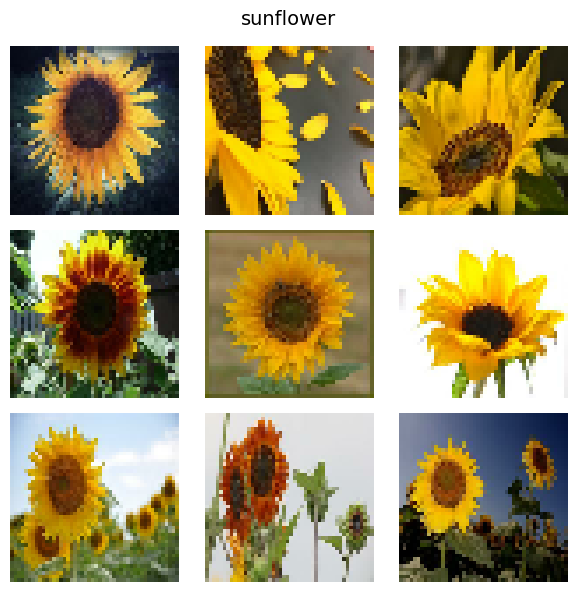

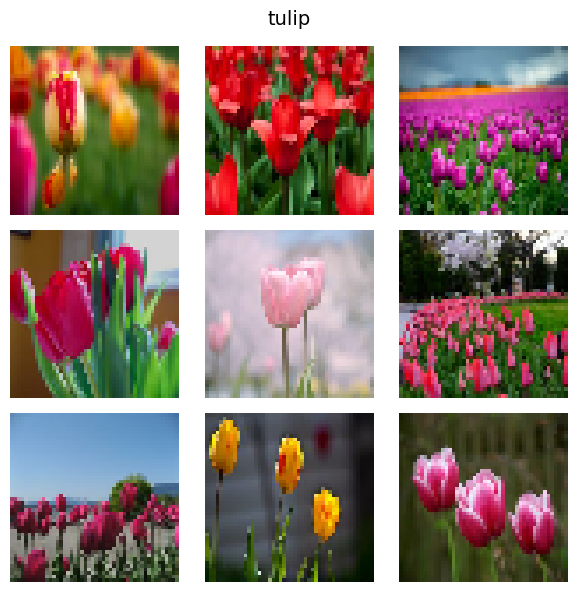

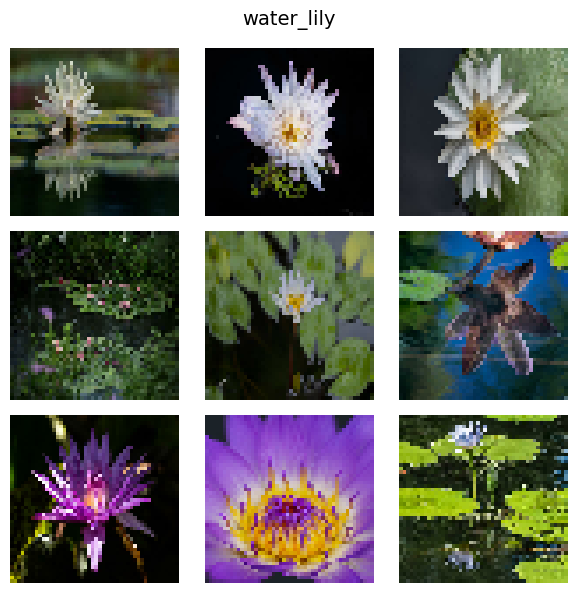

In [17]:
# PARTIE 1 : Exploration et visualisation des données

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(HEIGHT, WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# IMPORTANT : on utilise l'ordre réel détecté par Keras, pas une liste manuelle,
# pour éviter tout décalage entre les indices et les noms de classes
CLASS_NAMES = train_dataset.class_names
print("Classes détectées :", CLASS_NAMES)

# Nombre d'images par classe (demandé par l'énoncé, Partie 1)
for class_name in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, class_name)
    n_images = len(os.listdir(class_path))
    print(f"{class_name}: {n_images} images")


def visualize_images(dataset, class_names, n_classes=14):
    # Affiche une grille 3x3 d'images pour chaque classe
    images_by_class = {i: [] for i in range(n_classes)}

    for images, labels in dataset.unbatch():
        label_idx = tf.argmax(labels).numpy()
        if len(images_by_class[label_idx]) < 9:
            images_by_class[label_idx].append(images.numpy())
        if all(len(v) >= 9 for v in images_by_class.values()):
            break

    for class_idx, imgs in images_by_class.items():
        if len(imgs) == 0:
            continue
        fig, axes = plt.subplots(3, 3, figsize=(6, 6))
        fig.suptitle(class_names[class_idx], fontsize=14)
        for i, ax in enumerate(axes.flatten()):
            if i < len(imgs):
                ax.imshow(imgs[i].astype('uint8'))
            ax.axis('off')
        plt.tight_layout()
        plt.show()

visualize_images(train_dataset, CLASS_NAMES)

In [18]:
# PARTIE 2 : Architecture du modèle CNN

def build_model(input_shape=(HEIGHT, WIDTH, 3), num_classes=NUM_CLASSES):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1.0 / 255),

        # Premier bloc de convolution : détecte les patterns simples (bords, textures)
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Deuxième bloc : patterns plus complexes (formes, motifs)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Troisième bloc : patterns de haut niveau (parties de fleurs)
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,277,646 (4.87 MB)

 Trainable params: 1,277,198 (4.87 MB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
# PARTIE 3 : Hyperparamètres et compilation

optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [20]:
# PARTIE 4 : Augmentation des données
# Choix : on utilise les couches Keras d'augmentation (RandomFlip, RandomRotation, etc.)
# plutôt que ImageDataGenerator, car elles s'intègrent nativement au pipeline tf.data
# issu de image_dataset_from_directory et sont plus performantes (exécution sur GPU).

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
])

train_augmented = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

AUTOTUNE = tf.data.AUTOTUNE
train_augmented = train_augmented.prefetch(buffer_size=AUTOTUNE)
val_dataset     = val_dataset.prefetch(buffer_size=AUTOTUNE)

history = model.fit(
    train_augmented,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 136s 308ms/step - accuracy: 0.3705 - loss: 1.9455 - val_accuracy: 0.2551 - val_loss: 3.1856 - learning_rate: 5.0000e-04
Epoch 2/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 134s 291ms/step - accuracy: 0.4589 - loss: 1.5757 - val_accuracy: 0.5408 - val_loss: 1.6670 - learning_rate: 5.0000e-04
Epoch 3/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 121s 283ms/step - accuracy: 0.5096 - loss: 1.4214 - val_accuracy: 0.4694 - val_loss: 1.7902 - learning_rate: 5.0000e-04
Epoch 4/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 121s 283ms/step - accuracy: 0.5483 - loss: 1.3238 - val_accuracy: 0.4796 - val_loss: 1.7063 - learning_rate: 5.0000e-04
Epoch 5/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 128s 299ms/step - accuracy: 0.5691 - loss: 1.2567 - val_accuracy: 0.5000 - val_loss: 1.6905 - learning_rate: 5.0000e-04
Epoch 6/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 124s 289ms/step - accuracy: 0.6177 - loss: 1.0957 - val_accuracy: 0.5714 - val_loss: 1.2484 - learning_rate: 2.5000e-04
Epoch 7/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 

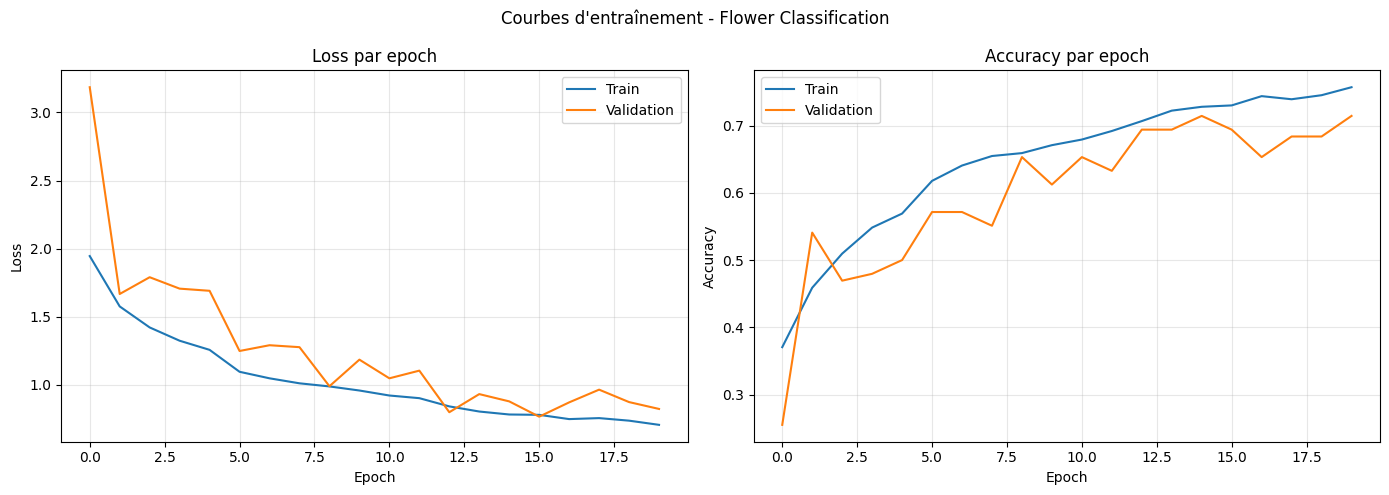


Rapport de classification :
                  precision    recall  f1-score   support

         astilbe       0.62      0.71      0.67         7
      bellflower       0.67      0.86      0.75         7
black_eyed_susan       0.88      1.00      0.93         7
       calendula       0.71      0.71      0.71         7
california_poppy       1.00      0.57      0.73         7
       carnation       0.60      0.43      0.50         7
    common_daisy       0.71      0.71      0.71         7
       coreopsis       1.00      0.57      0.73         7
       dandelion       0.80      0.57      0.67         7
            iris       1.00      0.71      0.83         7
            rose       0.75      0.43      0.55         7
       sunflower       0.67      0.86      0.75         7
           tulip       0.86      0.86      0.86         7
      water_lily       0.44      1.00      0.61         7

        accuracy                           0.71        98
       macro avg       0.76      0.71    

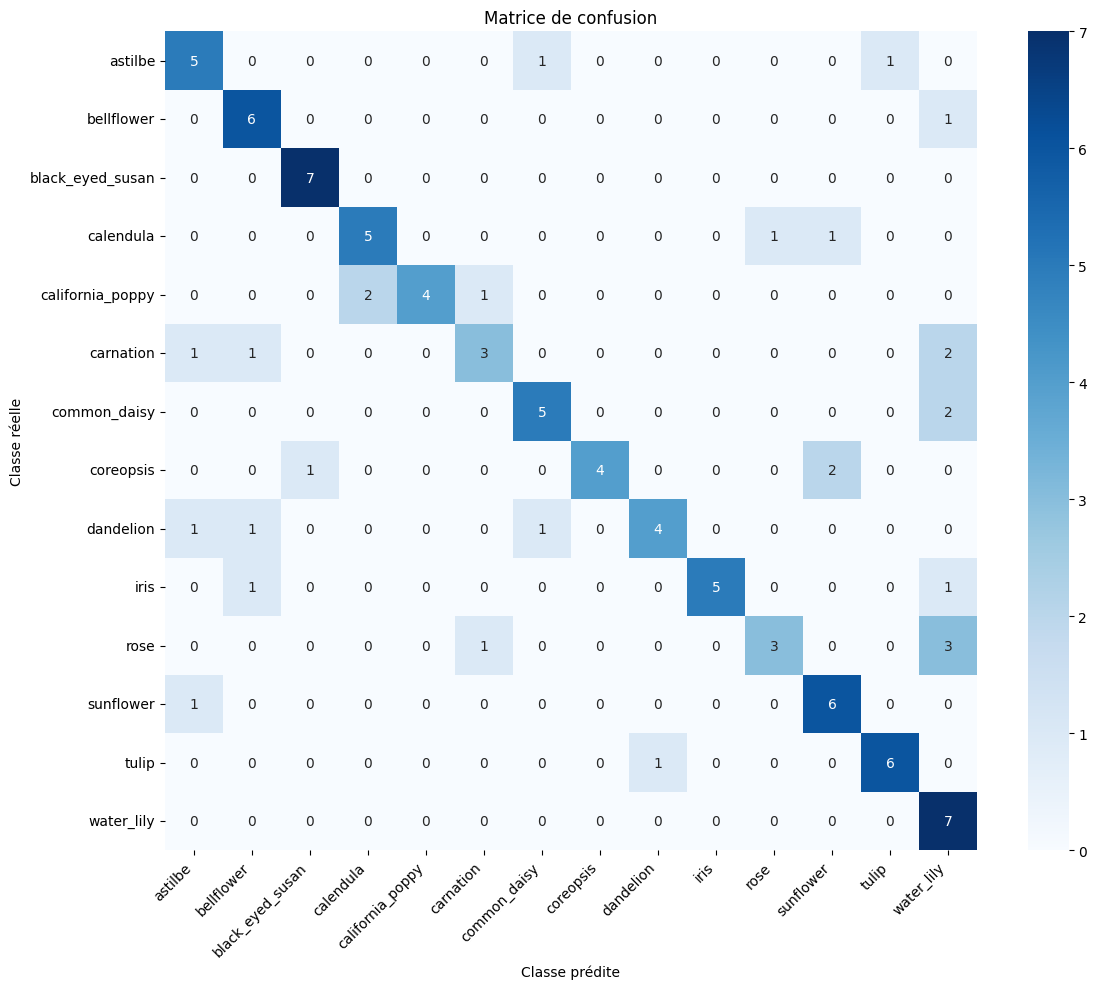

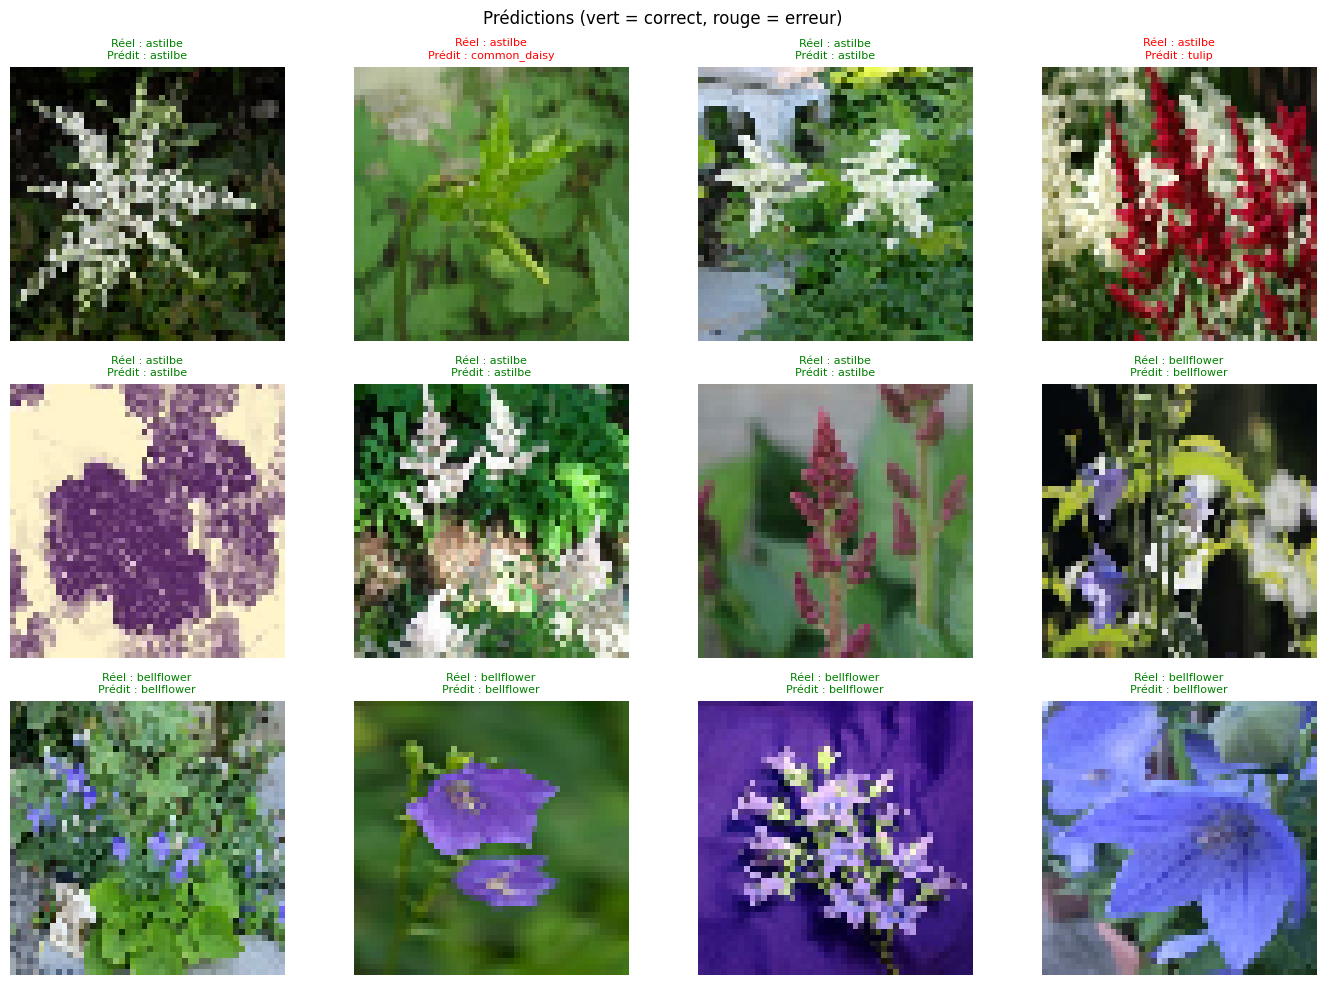

In [21]:
# PARTIE 5 : Évaluation des performances

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Train')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_title('Loss par epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'],     label='Train')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_title('Accuracy par epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Courbes d\'entraînement - Flower Classification')
plt.tight_layout()
plt.show()

y_true = []
y_pred = []

for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(predictions, axis=1).numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nRapport de classification :")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Matrice de confusion')
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
sample_images, sample_labels = next(iter(val_dataset))
sample_preds = model.predict(sample_images, verbose=0)

for i, ax in enumerate(axes.flatten()):
    if i >= len(sample_images):
        break
    img = sample_images[i].numpy().astype('uint8')
    true_label = tf.argmax(sample_labels[i]).numpy()
    pred_label = np.argmax(sample_preds[i])
    color = 'green' if true_label == pred_label else 'red'
    ax.imshow(img)
    ax.set_title(
        f"Réel : {CLASS_NAMES[true_label]}\nPrédit : {CLASS_NAMES[pred_label]}",
        color=color, fontsize=8
    )
    ax.axis('off')

plt.suptitle('Prédictions (vert = correct, rouge = erreur)')
plt.tight_layout()
plt.show()

In [22]:
# PARTIE 6 (optionnel) : Sauvegarde du modèle

model.save('/content/drive/MyDrive/flower_classifier.keras')
print("Modèle sauvegardé sous 'flower_classifier.keras'")

# Pour recharger le modèle plus tard
# model = keras.models.load_model('/content/drive/MyDrive/flower_classifier.keras')<

Modèle sauvegardé sous 'flower_classifier.keras'
